In [ ]:
!pip install ultralytics --no-deps

In [ ]:
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
import shutil
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

import seaborn as sns

In [ ]:
#importa dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alkanerturan/vehicledetection")

print("Path to dataset files:", path)

100%|██████████| 62.8M/62.8M [00:04<00:00, 14.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alkanerturan/vehicledetection/versions/3


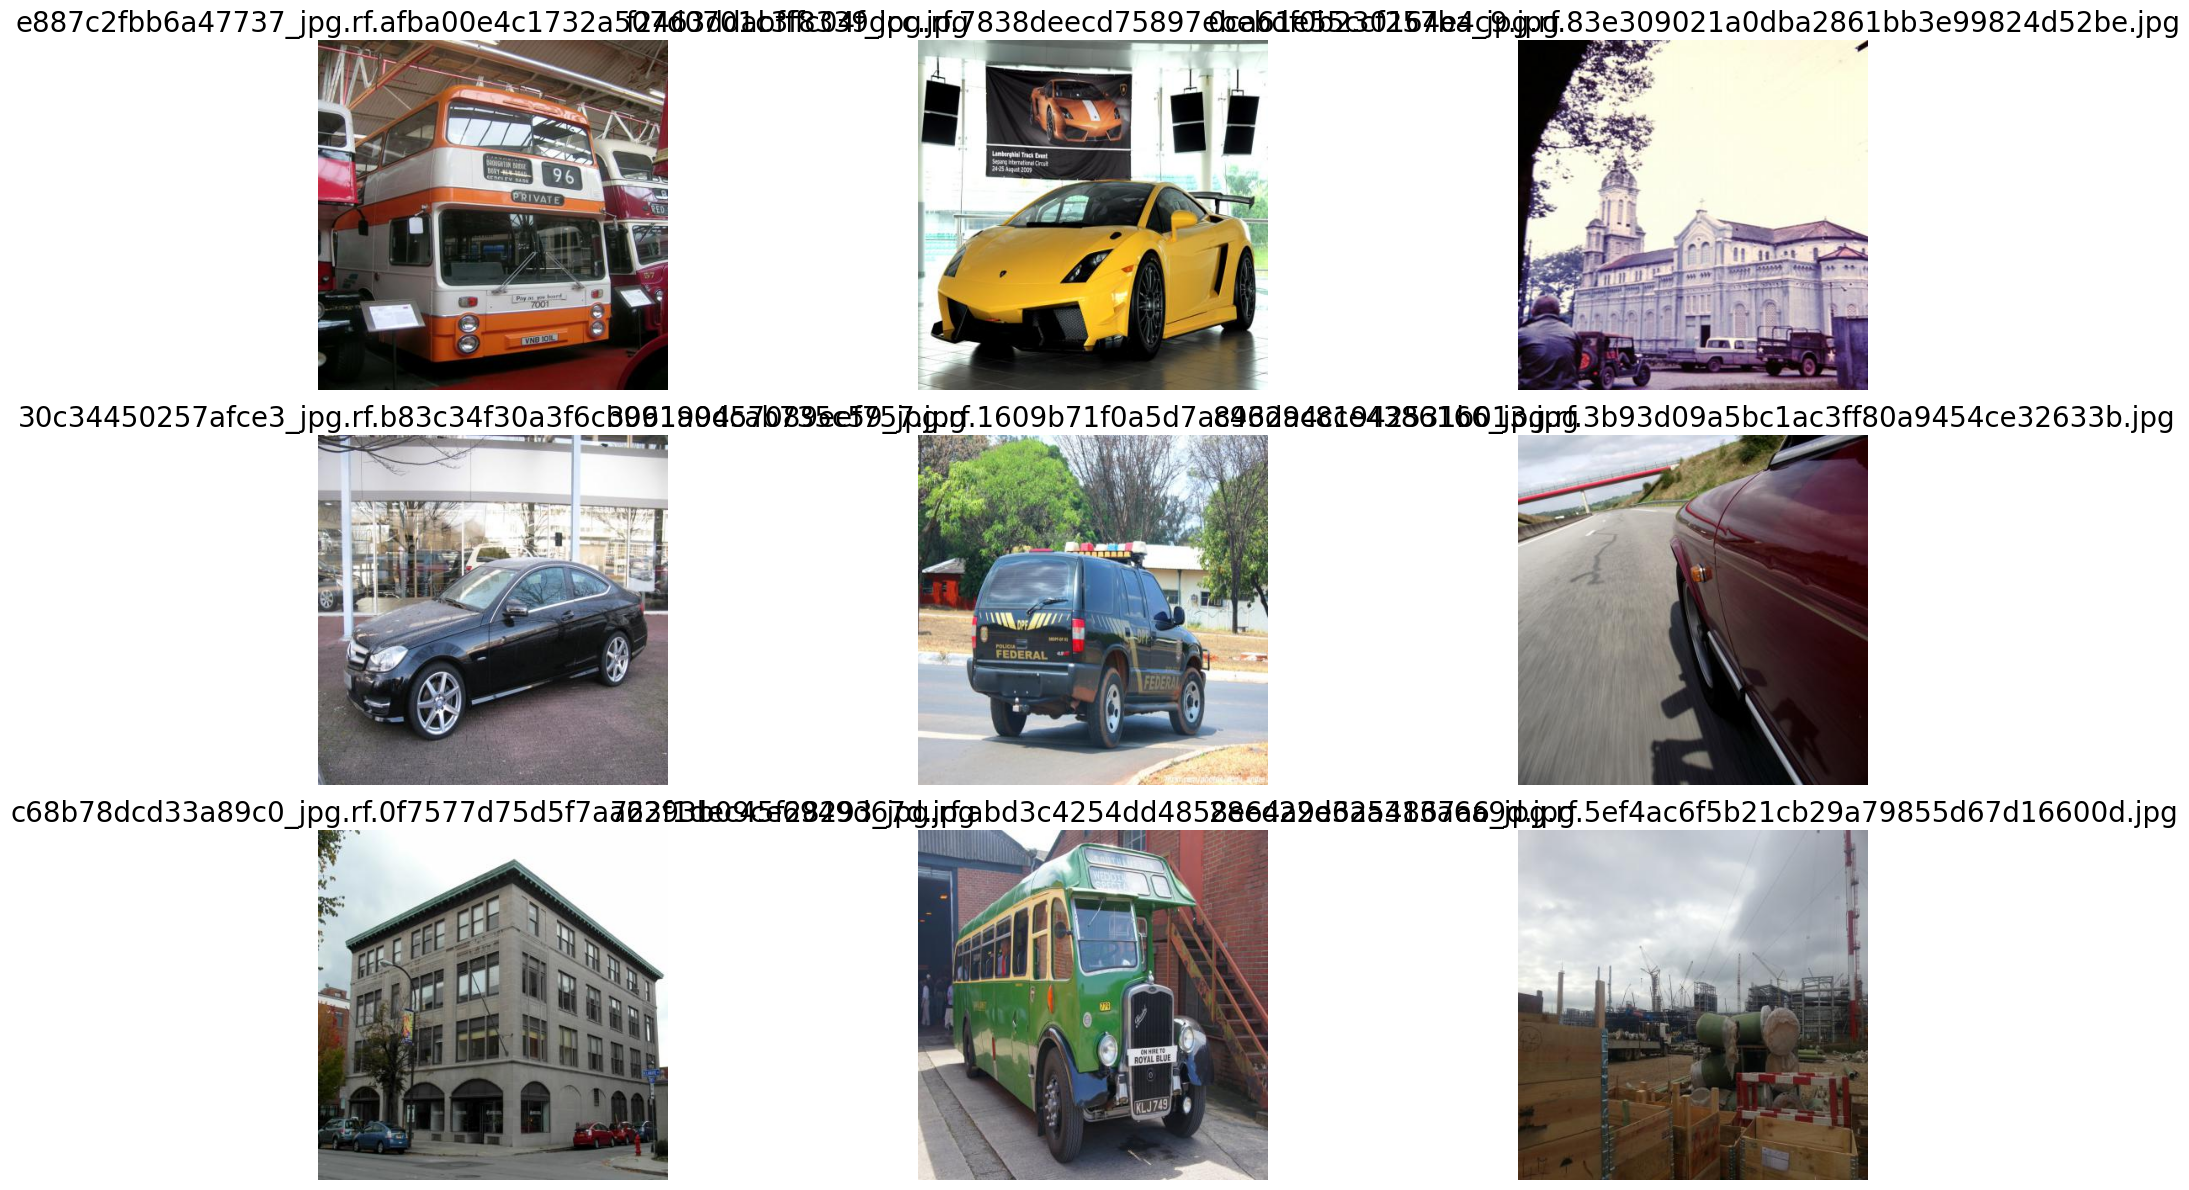

In [ ]:
#obtiene las imagenes del entrenamiento y muestra algunas
train_images_dir = Path("/kaggle/input/vehicledetection/VehiclesDetectionDataset/train/images")



image_files = list(train_images_dir.glob("*.jpg"))

sample_files = random.sample(image_files, min(9, len(image_files)))

fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_files):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(img_path.name, fontsize=20)

plt.tight_layout()
plt.show()

Train Image count: 878
Val Image count: 878
Test Image count: 878


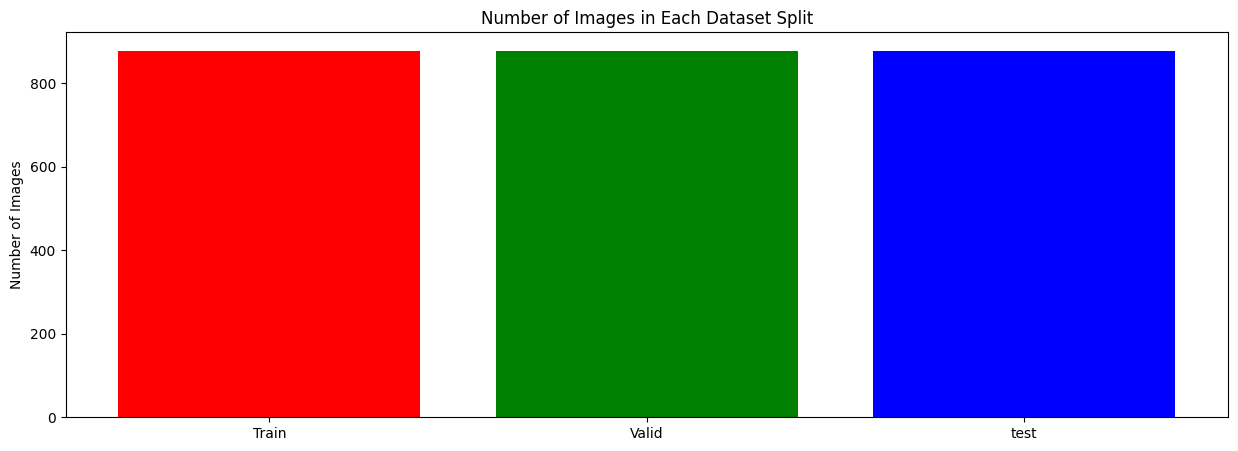

In [ ]:
#cuenta las imagenes del dataset
train_images_dir = Path("/kaggle/input/vehicledetection/VehiclesDetectionDataset/train/images/")
valid_images_dir = Path("/kaggle/input/vehicledetection/VehiclesDetectionDataset/valid/images/")
test_images_dir = Path("/kaggle/input/vehicledetection/VehiclesDetectionDataset/test/images/")



train_count = len(list(train_images_dir.glob("*.jpg")))
valid_count = len(list(train_images_dir.glob("*.jpg")))
test_count = len(list(train_images_dir.glob("*.jpg")))


print(f"Train Image count: {train_count}")
print(f"Val Image count: {valid_count}")
print(f"Test Image count: {test_count}")


plt.figure(figsize=(15,5))
plt.bar(['Train', 'Valid','test'], [train_count, valid_count,test_count], color=['red', 'green', 'blue'])
plt.title('Number of Images in Each Dataset Split')
plt.ylabel('Number of Images')
plt.show()

In [ ]:
#categorias
yaml_path = "/kaggle/input/vehicledetection/VehiclesDetectionDataset/dataset.yaml"

In [ ]:
#yolo
model = YOLO("yolov8s.pt")

In [ ]:
###
model.info()

####

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients


(129, 11166560, 0, 0.0)

In [ ]:
# ENTRENAMIENTO DEL MODELO ADAM 80
model.train(
    data=yaml_path,
    patience=20,
    epochs=80,
    imgsz=640,
    batch=16,
    lr0=0.001,
    optimizer="AdamW",
)

Ultralytics 8.3.230 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/vehicledetection/VehiclesDetectionDataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train10, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bef704e1970>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
#MUESTRA LOS ULTIMOS ENTRENAMIENTOS
ls runs/detect/


train  train10	train2	train3	train4	train5	train6	train7	train8	train9


# MATRIZ DE CONFUSIÓN

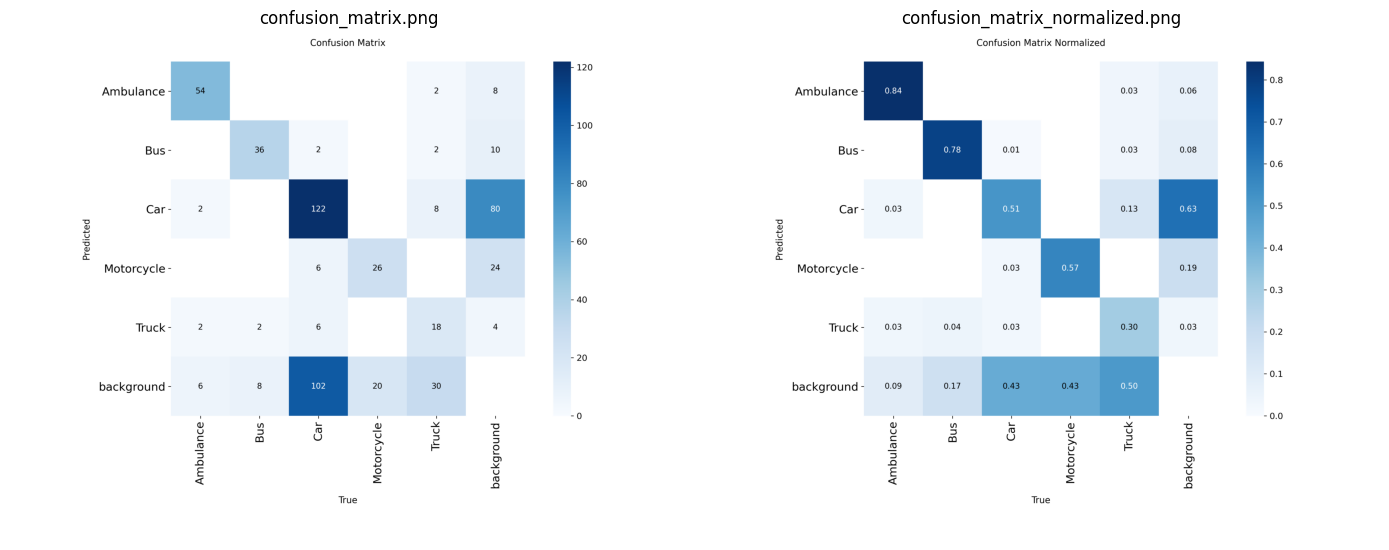

In [ ]:
#evaluar que tan bien funciona yolo
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("runs/detect/train10")

plot_files = [
    "confusion_matrix.png",
    "confusion_matrix_normalized.png"
]

existing = [output_dir / f for f in plot_files if (output_dir / f).exists()]

plt.figure(figsize=(14, 6))

for i, img_path in enumerate(existing):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()



In [ ]:
model_result = pd.read_csv("runs/detect/train10/results.csv")



In [ ]:
#resultados de modelo entrenado
model_result

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,7.61265,1.21476,2.37620,1.49606,0.25219,0.32139,0.22502,0.10847,1.61805,3.16428,2.23572,0.067600,0.000327,0.000327
1,2,14.27990,1.20506,1.86894,1.50815,0.23639,0.49102,0.28376,0.15617,1.51129,2.92385,2.00635,0.034592,0.000652,0.000652
2,3,20.82870,1.20382,1.77428,1.50394,0.19796,0.39974,0.20115,0.09568,1.90048,4.88928,2.23975,0.001575,0.000969,0.000969
3,4,27.33140,1.23595,1.79645,1.52792,0.36322,0.30725,0.23536,0.10441,1.69333,2.88807,2.03676,0.000963,0.000963,0.000963
4,5,33.72790,1.20612,1.63950,1.47294,0.39656,0.38952,0.32963,0.18576,1.69643,2.37192,2.04174,0.000950,0.000950,0.000950
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,490.90400,0.36764,0.28047,0.91213,0.71379,0.55718,0.62086,0.46213,1.13778,1.44557,1.59525,0.000072,0.000072,0.000072
76,77,497.28000,0.35217,0.27671,0.90146,0.62976,0.59778,0.61623,0.46398,1.12901,1.44420,1.59102,0.000060,0.000060,0.000060
77,78,503.58300,0.33482,0.27502,0.88683,0.61933,0.58948,0.61228,0.45861,1.13367,1.50446,1.59813,0.000047,0.000047,0.000047
78,79,509.98500,0.34222,0.26970,0.88855,0.71485,0.52157,0.60693,0.45461,1.14263,1.53228,1.60135,0.000035,0.000035,0.000035


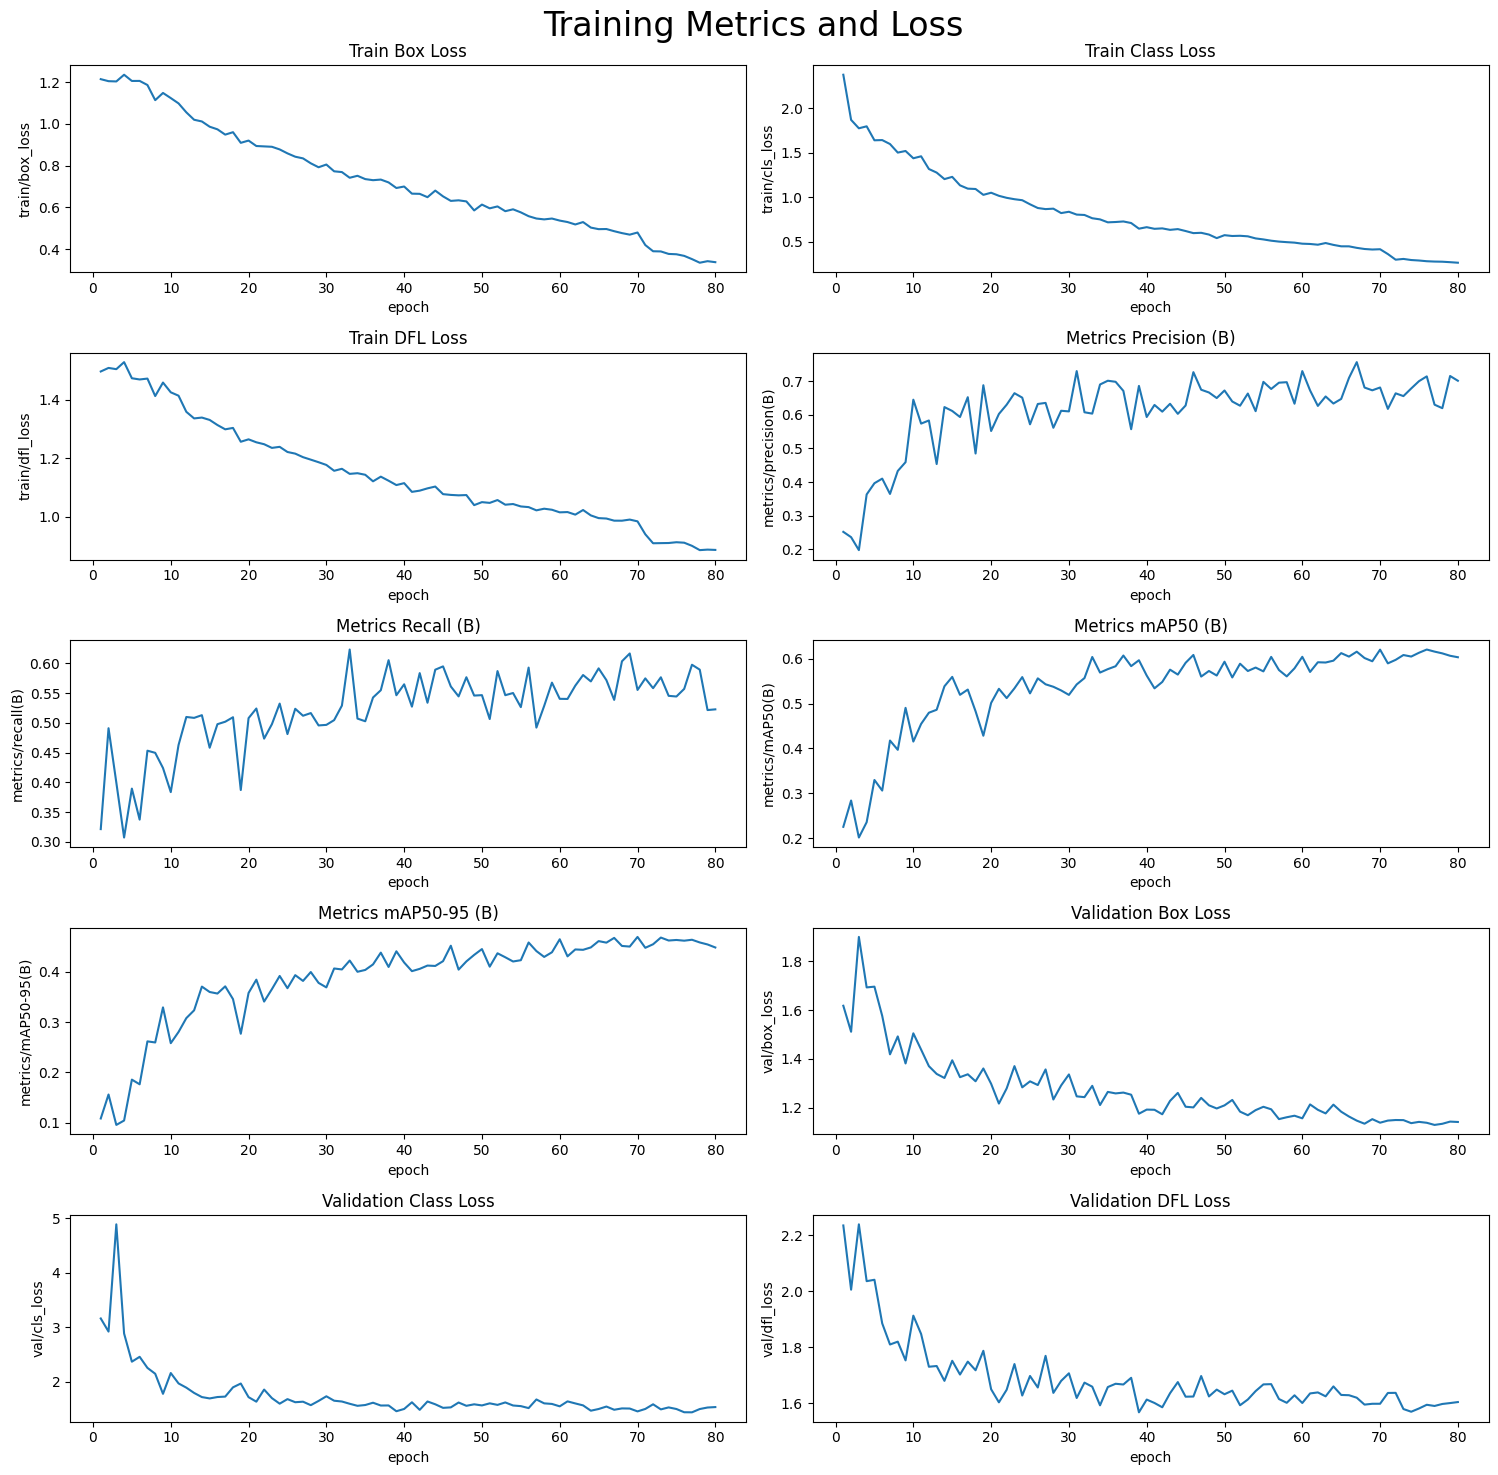

In [ ]:
model_result.columns = model_result.columns.str.strip()

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

sns.lineplot(x='epoch', y='train/box_loss', data=model_result, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=model_result, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=model_result, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=model_result, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=model_result, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=model_result, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=model_result, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=model_result, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=model_result, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=model_result, ax=axs[4,1])

axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')

plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()




image 1/1 /kaggle/input/vehicledetection/VehiclesDetectionDataset/test/images/00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg: 640x640 1 Ambulance, 8.5ms
Speed: 2.6ms preprocess, 8.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg: Detected boxes count: 1

image 1/1 /kaggle/input/vehicledetection/VehiclesDetectionDataset/test/images/2c21c734126f9f69_jpg.rf.5b6a30b89f06d6dbe401038cb7caf396.jpg: 640x640 1 Ambulance, 1 Car, 7.8ms
Speed: 2.4ms preprocess, 7.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
2c21c734126f9f69_jpg.rf.5b6a30b89f06d6dbe401038cb7caf396.jpg: Detected boxes count: 2

image 1/1 /kaggle/input/vehicledetection/VehiclesDetectionDataset/test/images/47b09b34e24b4039_jpg.rf.9274b35afd28c89ed4221e69e765e71d.jpg: 640x640 2 Buss, 8.0ms
Speed: 2.4ms preprocess, 8.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
47b09b34e24b4039_jpg.rf.9274b35afd

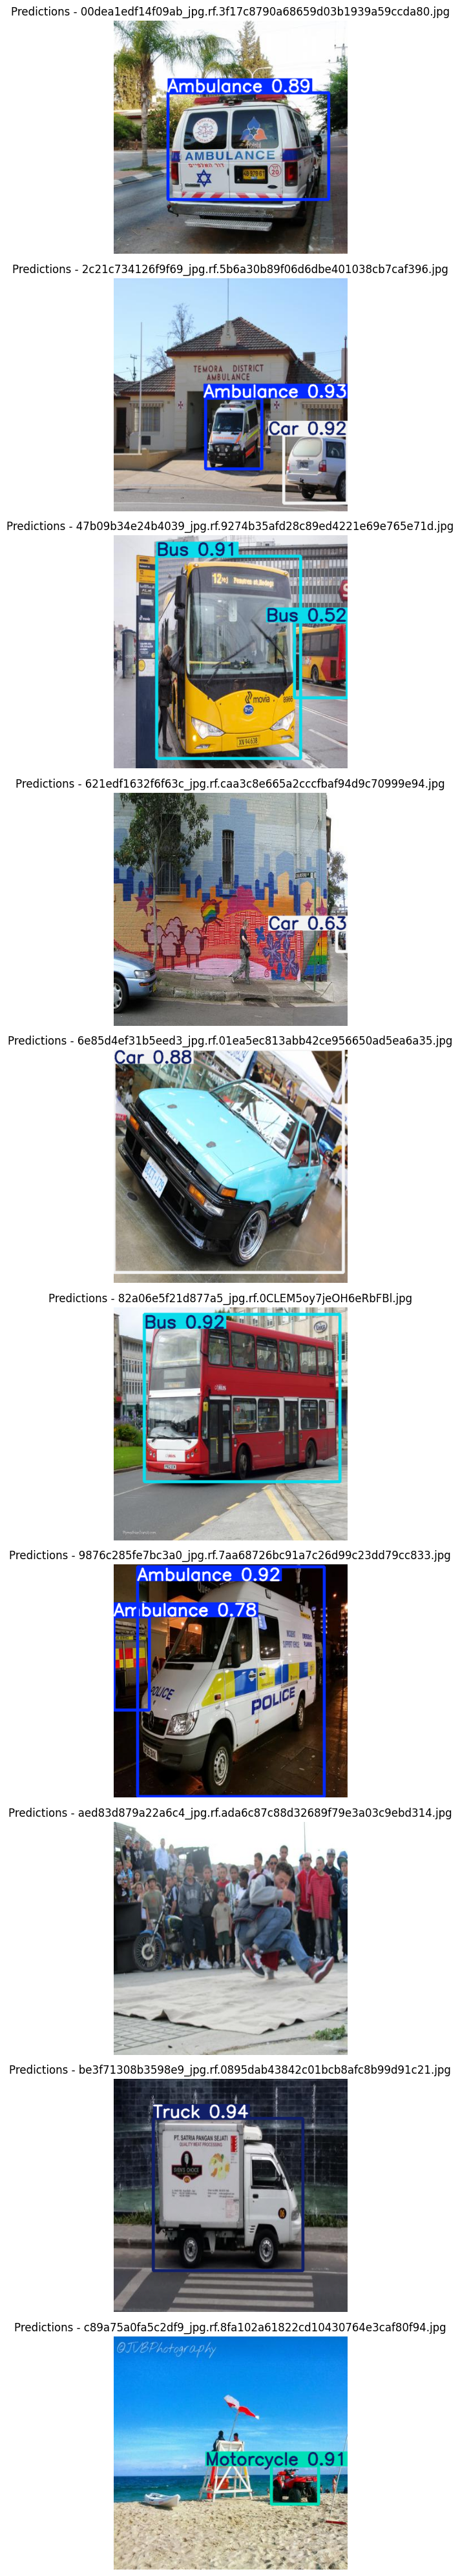

In [ ]:

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Ruta de tus imágenes de test
test_images_path = Path("/kaggle/input/vehicledetection/VehiclesDetectionDataset/test/images/")

# Obtener lista de imágenes
image_files = sorted([f for f in test_images_path.iterdir() if f.suffix.lower() == '.jpg'])

# Seleccionar 10 imágenes espaciadas
step = max(1, len(image_files) // 10)
selected_images = image_files[::step][:10]

# Crear figura con una fila por imagen
rows = len(selected_images)
fig, axes = plt.subplots(rows, 1, figsize=(10, rows * 4))

# Cargar tu modelo YOLO entrenado
test_model = YOLO("runs/detect/train10/weights/best.pt")

# Procesar cada imagen
for i, img_path in enumerate(selected_images):
    results = test_model.predict(source=str(img_path), imgsz=640, conf=0.5)

    print(f"{img_path.name}: Detected boxes count: {len(results[0].boxes)}")

    annotated = results[0].plot(line_width=3)
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[i].imshow(annotated_rgb)
    axes[i].set_title(f"Predictions - {img_path.name}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from pathlib import Path

# Ruta del archivo results.csv en tu entrenamiento
results_path = Path("runs/detect/train10/results.csv")

# Cargar resultados
df = pd.read_csv(results_path)

# Obtener la precisión final (última fila, columna 'metrics/precision(B)')
precision = df["metrics/precision(B)"].iloc[-1]

print(f"precisión del modelo: {precision:.4%}")

precisión del modelo: 70.0730%


In [ ]:
#Descargar modelo
from google.colab import files
files.download("runs/detect/train10/weights/best.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>